# 01a — Clean one 3-D detector acquisition

This notebook loads one acquisition and its dark as 3-D stacks, fits and subtracts the dark, optionally removes the horizontal detector band, thresholds individual frames, averages them, and saves one file for that image ID. Tune the visible parameters on one image, then use the final batch cell without plots.

Mask convention: `1 = unusable`. `mask_detector.png` and `mask_beamstop_<IMAGE_ID>.png` are loaded from `processed/mask_pixels/`; their union is saved as `mask_pixel`.


In [107]:
# Configure Qt before importing pyplot or any other GUI-aware library.
import os
import sys
from os.path import join

BASEFOLDER = os.path.abspath(os.getcwd())
LIBRARY_FOLDER = join(BASEFOLDER, "library")
if LIBRARY_FOLDER not in sys.path:
    sys.path.insert(0, LIBRARY_FOLDER)

from notebook_setup import configure_matplotlib_qt
MATPLOTLIB_BACKEND = configure_matplotlib_qt()
print("Matplotlib backend:", MATPLOTLIB_BACKEND)

import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter

BASEFOLDER = os.path.abspath(os.getcwd())
sys.path.insert(0, join(BASEFOLDER, "library"))
from interactive import cimshow

from data_loading import SextantsNexusLoader, load_processing
from image_preprocessing import fit_dark_frame, fit_horizontal_band, load_detector_masks

print("Base folder:", BASEFOLDER)


Matplotlib backend: qt5 (pyqt5)
Base folder: /home/riccardo/Desktop/Github/FTH-Phase-Retrieval-2609-SOLEIL-SEXTANTS


## Load one acquisition and its dark

In [98]:
# Current experimental parameters, retained from the working notebook.
RAW_FOLDER = "/nfs/ruche/sextants-soleil/com-sextants/COMET_20260902_Cocoons_Laser/"
RAW_FOLDER = '/media/riccardo/My Book/Beamtimes/26_09_SOLEIL/COMET_20260902_Cocoons_Laser/'
IMAGE_ID = [565]
DARK_IDS = [574]
#IMAGE_ID = [415]
#DARK_IDS = [417]
USER = "rb"

MASK_FOLDER = join(BASEFOLDER, "processed", "mask_pixels")

loader = SextantsNexusLoader(RAW_FOLDER)

# load_processing always returns (2-D float average, 3-D float stack).
blind_average, raw_stack = load_processing(loader, IMAGE_ID)
dark_average, dark_stack = load_processing(loader, DARK_IDS)
blind_average = np.asarray(blind_average, dtype=float)
raw_stack = np.asarray(raw_stack, dtype=float)
dark_average = np.asarray(dark_average, dtype=float)
dark_stack = np.asarray(dark_stack, dtype=float)

print(f"Image {IMAGE_ID}: {raw_stack.shape}; blind average: {blind_average.shape}")
print(f"Dark {DARK_IDS}: {dark_stack.shape}; average: {dark_average.shape}")

blind_average=np.nan_to_num(blind_average)
dark_average=np.nan_to_num(dark_average)

Image [565]: (1, 2048, 2048); blind average: (2048, 2048)
Dark [574]: (11, 2048, 2048); average: (2048, 2048)


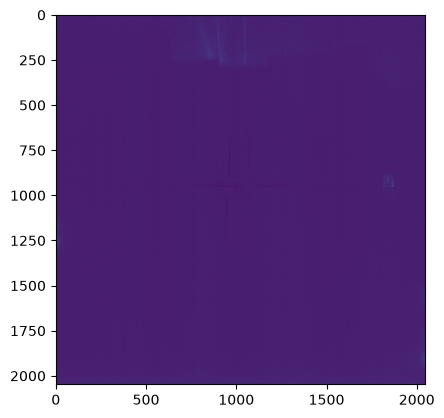

In [99]:
plt.close("all")
%matplotlib inline

temp=dark_average.copy()
temp0=np.average(temp[:, 980:1020], axis=1)
temp0=np.tile(temp0, (temp0.size,1)).T
temp0=1
fig,ax=plt.subplots()
ax.imshow(temp/temp0)
plt.imsave("mask_beamstop_415.png", temp/temp0, vmin=0.8, vmax=1.5)

In [100]:
factor=np.nanmean(blind_average[100:200,100:200])/np.nanmean(dark_average[100:200,100:200])

-23.257393763951313 23.08623511644356


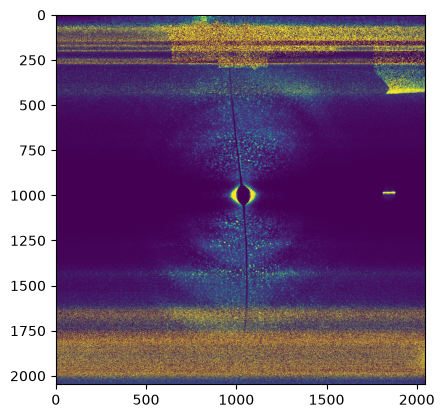

In [106]:
import scipy

plt.close("all")
%matplotlib inline

temp=blind_average.copy() - factor*dark_average
temp0=scipy.ndimage.gaussian_filter(temp, sigma=10)
temp0=np.average(temp0[:, 1010:1070], axis=1)
temp0=np.tile(temp0, (temp0.size,1)).T
#temp0-=(np.amin(temp0)+0.1)
#temp0=1


temp=(temp/temp0)

mi,ma=np.percentile(temp, (2,98))
print(mi,ma)
mi,ma=-0,5
#mi=-2
#ma=1
#mi,ma=0,5
fig,ax=plt.subplots()
ax.imshow(temp, vmin=mi, vmax=ma)
plt.show()
plt.imsave("mask_beamstop_615.png", temp, vmin=mi, vmax=ma)

# Load detector and beamstop masks

In [97]:
# Expected files:
#   processed/mask_pixels/mask_detector.png
#   processed/mask_pixels/mask_beamstop_569.png
mask_detector, mask_beamstop, mask_pixel = load_detector_masks(
    MASK_FOLDER, IMAGE_ID, blind_average.shape
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for axis, mask, title in zip(
    axes,
    (mask_detector, mask_beamstop, mask_pixel),
    ("detector mask", "beamstop mask", "combined mask_pixel"),
):
    axis.imshow(mask, cmap="gray", vmin=0, vmax=1)
    axis.set_title(title)
    axis.set_axis_off()
plt.tight_layout()
plt.show()
print("Combined masked pixels:", int(mask_pixel.sum()))


FileNotFoundError: [Errno 2] No such file or directory: '/home/riccardo/Desktop/Github/FTH-Phase-Retrieval-2609-SOLEIL-SEXTANTS/processed/mask_pixels/mask_beamstop_[615].png'

## Fit and subtract the averaged dark

In [71]:
# These parameters are beside the dark operation they control.
DARK_FIT_PERCENTILE = 100
DARK_FIT_ROWS = slice(0, 600)
DARK_FIT_COLUMNS = slice(0, 200)
DARK_FIT_STRIDE = 1

corrected_frames = []
dark_scales = []
dark_offsets = []

for raw_frame in raw_stack:
    corrected_frame, scale, offset, _, _ = fit_dark_frame(
        raw_frame,
        dark_average,
        DARK_FIT_ROWS,
        DARK_FIT_COLUMNS,
        percentile=DARK_FIT_PERCENTILE,
        stride=DARK_FIT_STRIDE,
        mask=mask_detector,
    )
    corrected_frames.append(corrected_frame)
    dark_scales.append(scale)
    dark_offsets.append(offset)

corrected_stack = np.asarray(corrected_frames, dtype=float)
dark_scales = np.asarray(dark_scales)
dark_offsets = np.asarray(dark_offsets)
print("Mean dark scale:", dark_scales.mean())
print("Mean dark offset:", dark_offsets.mean())


Mean dark scale: 2.995638434899534
Mean dark offset: 655.2583016378613


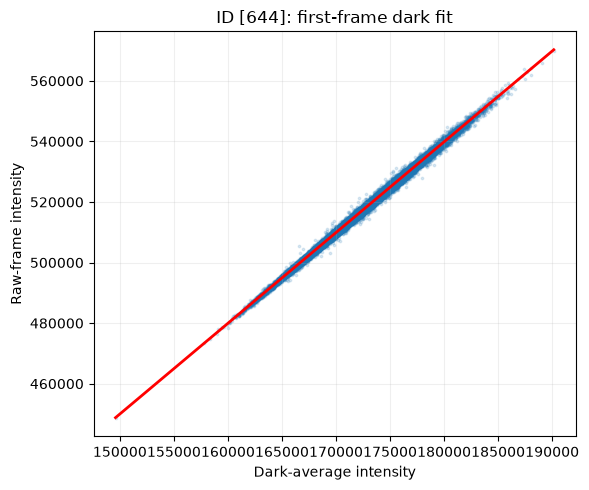

In [72]:
# Inspect the first frame's dark fit using exactly the fitted pixels.
_, _, _, dark_values, fitted_pixels = fit_dark_frame(
    raw_stack[0], dark_average,
    DARK_FIT_ROWS, DARK_FIT_COLUMNS,
    percentile=DARK_FIT_PERCENTILE,
    stride=DARK_FIT_STRIDE,
    mask=mask_detector,
)
image_values = raw_stack[0, DARK_FIT_ROWS, DARK_FIT_COLUMNS][
    ::DARK_FIT_STRIDE, ::DARK_FIT_STRIDE
].ravel()

fig, axis = plt.subplots(figsize=(6, 5))
axis.scatter(dark_values[fitted_pixels], image_values[fitted_pixels], s=3, alpha=0.15)
x_line = np.linspace(dark_values[fitted_pixels].min(), dark_values[fitted_pixels].max(), 200)
axis.plot(x_line, dark_scales[0] * x_line + dark_offsets[0], color="red", linewidth=2)
axis.set_title(f"ID {IMAGE_ID}: first-frame dark fit")
axis.set_xlabel("Dark-average intensity")
axis.set_ylabel("Raw-frame intensity")
axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Fit the horizontal band artifact

/home/riccardo/Desktop/Github/FTH-Phase-Retrieval-2609-SOLEIL-SEXTANTS/library/image_preprocessing.py:126: RuntimeWarning: Mean of empty slice
  return np.nanmean(values, axis=1)
/home/riccardo/Desktop/Github/FTH-Phase-Retrieval-2609-SOLEIL-SEXTANTS/library/image_preprocessing.py:128: RuntimeWarning: Mean of empty slice
  measured_profile = np.nanmean(


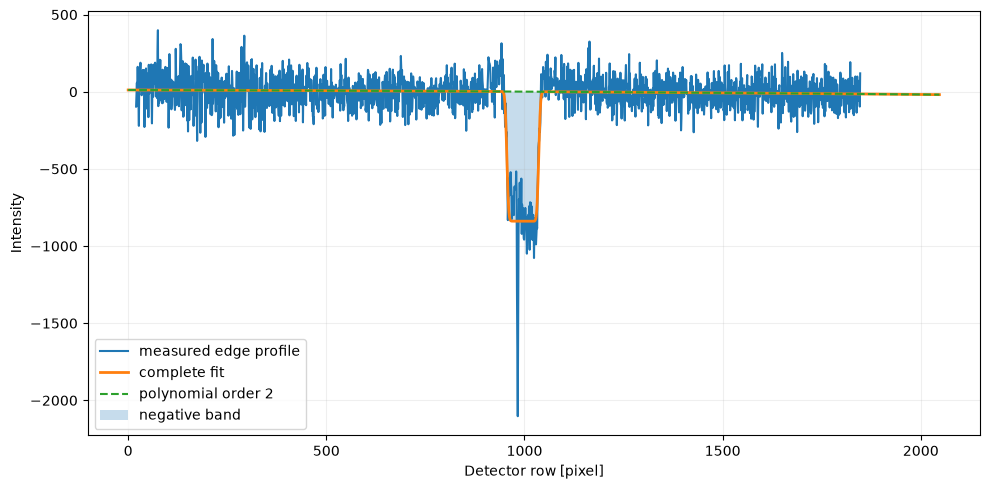

Polynomial coefficients c0, c1, ...: [ 6.59499210e-01 -1.47802092e-02 -4.01059168e-06]
Band amplitude, center, width, edge: 840.1402558774828 995.6299982309594 80.44083770401447 3.6224790441953165


In [73]:
# Set CORRECT_HORIZONTAL_BAND=False to skip this operation.
CORRECT_HORIZONTAL_BAND = True
BAND_EDGE_COLUMNS = 20
BAND_SKIPPED_EDGE_COLUMNS = 0
BAND_POLYNOMIAL_ORDER = 2
BAND_CENTER = 1024
BAND_WIDTH = 80
BAND_EDGE = 11
SUBTRACT_POLYNOMIAL_BACKGROUND = False

# Ignore unreliable top and bottom rows while estimating the profile.
band_fit_mask = mask_detector.copy()
band_fit_mask[:20, :] = 1
band_fit_mask[-200:, :] = 1

corrected_average = np.mean(corrected_stack, axis=0, dtype=np.float64)
if CORRECT_HORIZONTAL_BAND:
    band_fit = fit_horizontal_band(
        corrected_average,
        edge_columns=BAND_EDGE_COLUMNS,
        skipped_edge_columns=BAND_SKIPPED_EDGE_COLUMNS,
        polynomial_order=BAND_POLYNOMIAL_ORDER,
        band_center=BAND_CENTER,
        band_width=BAND_WIDTH,
        band_edge=BAND_EDGE,
        mask=band_fit_mask,
    )

    fig, axis = plt.subplots(figsize=(10, 5))
    axis.plot(band_fit.rows, band_fit.measured_profile, label="measured edge profile")
    axis.plot(band_fit.rows, band_fit.fitted_profile, linewidth=2, label="complete fit")
    axis.plot(band_fit.rows, band_fit.polynomial_profile, "--", label=f"polynomial order {BAND_POLYNOMIAL_ORDER}")
    axis.fill_between(
        band_fit.rows, band_fit.polynomial_profile, band_fit.fitted_profile,
        alpha=0.25, label="negative band",
    )
    axis.set_xlabel("Detector row [pixel]")
    axis.set_ylabel("Intensity")
    axis.legend()
    axis.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    corrected_stack = corrected_stack - band_fit.band_image
    if SUBTRACT_POLYNOMIAL_BACKGROUND:
        corrected_stack = corrected_stack - band_fit.polynomial_image

    print("Polynomial coefficients c0, c1, ...:", band_fit.polynomial_coefficients)
    print("Band amplitude, center, width, edge:", band_fit.band_amplitude, band_fit.band_center, band_fit.band_width, band_fit.band_edge)


## Choose the photon threshold

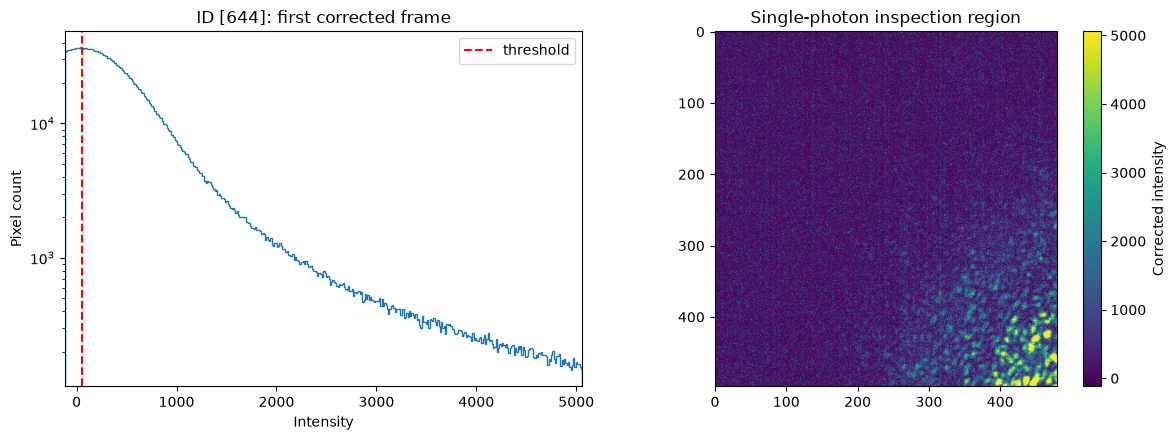

In [78]:
# Tune these values while viewing the histogram and single-photon region.
INTENSITY_THRESHOLD = 50.0
HISTOGRAM_RANGE = (-120, 5060)
HISTOGRAM_BINS = 400
PHOTON_VIEW_ROWS = slice(402, 900)
PHOTON_VIEW_COLUMNS = slice(420, 900)
USE_GAUSSIAN_DETECTION = False
GAUSSIAN_SIGMA = 2.0

representative_image = corrected_stack[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(
    representative_image[mask_detector == 0].ravel(),
    bins=HISTOGRAM_BINS, range=HISTOGRAM_RANGE, histtype="step",
)
axes[0].axvline(INTENSITY_THRESHOLD, color="red", linestyle="--", label="threshold")
axes[0].set_title(f"ID {IMAGE_ID}: first corrected frame")
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Pixel count")
axes[0].set_xlim(*HISTOGRAM_RANGE)
axes[0].set_yscale("log")
axes[0].legend()

photon_view = representative_image[PHOTON_VIEW_ROWS, PHOTON_VIEW_COLUMNS]
if USE_GAUSSIAN_DETECTION:
    detected = photon_view * (gaussian_filter(photon_view, GAUSSIAN_SIGMA) > INTENSITY_THRESHOLD / 2)
else:
    detected = photon_view * (photon_view > INTENSITY_THRESHOLD)
shown = axes[1].imshow(detected, vmin=HISTOGRAM_RANGE[0], vmax=HISTOGRAM_RANGE[1], cmap="viridis")
axes[1].set_title("Single-photon inspection region")
fig.colorbar(shown, ax=axes[1], label="Corrected intensity")
plt.tight_layout()
plt.show()


## Clean, average, compare, and save

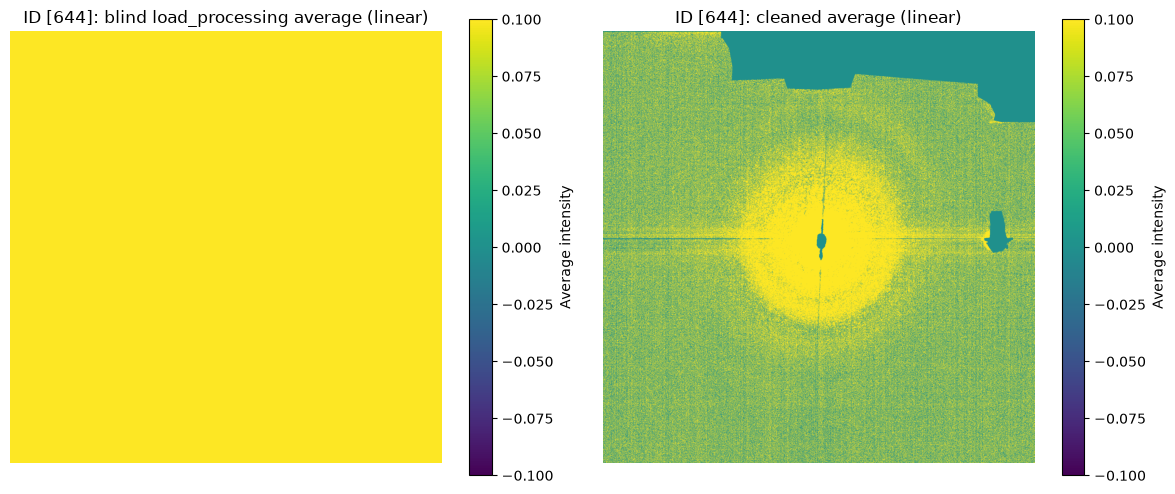

In [75]:
# Apply the selected photon rule independently to every frame.
if USE_GAUSSIAN_DETECTION:
    detection_stack = np.stack([
        frame * (gaussian_filter(frame, GAUSSIAN_SIGMA) > INTENSITY_THRESHOLD / 2)
        for frame in corrected_stack
    ])
    cleaned_stack = np.clip(detection_stack, 0, None)
else:
    cleaned_stack = np.clip(corrected_stack - INTENSITY_THRESHOLD, 0, None)

cleaned_stack[:, mask_pixel == 1] = 0
cleaned_average = np.mean(cleaned_stack, axis=0, dtype=np.float64)

display_values = np.concatenate((blind_average.ravel(), cleaned_average.ravel()))
display_values = display_values[np.isfinite(display_values)]
DISPLAY_PERCENTILES = (1, 10.9)
display_min, display_max = np.percentile(display_values, DISPLAY_PERCENTILES)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, image, title in zip(
    axes,
    (blind_average, cleaned_average),
    ("blind load_processing average", "cleaned average"),
):
    shown = axis.imshow(image, vmin=display_min, vmax=display_max, cmap="viridis")
    axis.set_title(f"ID {IMAGE_ID}: {title} (linear)")
    axis.set_axis_off()
    fig.colorbar(shown, ax=axis, label="Average intensity")
plt.tight_layout()
plt.show()


In [ ]:
# Output settings are here because they are first used in this cell.
OUTPUT_FOLDER = join(BASEFOLDER, "processed", "cleaned_acquisitions")

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metadata = loader.load(IMAGE_ID).metadata
output_file = join(OUTPUT_FOLDER, f"cleaned_ImId_{IMAGE_ID:04d}_{USER}.npz")

np.savez_compressed(
    output_file,
    image=cleaned_average,
    blind_average=blind_average,
    mask_detector=mask_detector,
    mask_beamstop=mask_beamstop,
    mask_pixel=mask_pixel,
    image_id=np.asarray(IMAGE_ID, dtype=int),
    dark_ids=np.asarray(DARK_IDS, dtype=int),
    threshold=np.asarray(INTENSITY_THRESHOLD, dtype=float),
    dark_scales=dark_scales,
    dark_offsets=dark_offsets,
    energy_eV=float(metadata["energy_eV"]),
    ccd_dist_m=float(metadata["ccd_dist_m"]),
    px_size_m=11.0e-6,
)
print("Saved:", output_file)


## Apply the tuned settings to more acquisitions

In [ ]:
# This cell reuses every setting chosen above and intentionally makes no plots.
BATCH_IMAGE_IDS = (
    list(range(609, 613))
    + list(range(589, 602))
    + list(range(575, 589))
)

for batch_image_id in BATCH_IMAGE_IDS:
    batch_blind_average, batch_raw_stack = load_processing(loader, batch_image_id)
    batch_raw_stack = np.asarray(batch_raw_stack, dtype=float)
    batch_detector_mask, batch_beamstop_mask, batch_pixel_mask = load_detector_masks(
        MASK_FOLDER, batch_image_id, batch_blind_average.shape
    )

    batch_corrected_frames = []
    batch_scales = []
    batch_offsets = []
    for raw_frame in batch_raw_stack:
        frame, scale, offset, _, _ = fit_dark_frame(
            raw_frame, dark_average,
            DARK_FIT_ROWS, DARK_FIT_COLUMNS,
            percentile=DARK_FIT_PERCENTILE,
            stride=DARK_FIT_STRIDE,
            mask=batch_detector_mask,
        )
        batch_corrected_frames.append(frame)
        batch_scales.append(scale)
        batch_offsets.append(offset)
    batch_corrected_stack = np.asarray(batch_corrected_frames, dtype=float)

    if CORRECT_HORIZONTAL_BAND:
        batch_band_mask = batch_detector_mask.copy()
        batch_band_mask[:20, :] = 1
        batch_band_mask[-200:, :] = 1
        batch_fit = fit_horizontal_band(
            np.mean(batch_corrected_stack, axis=0, dtype=np.float64),
            edge_columns=BAND_EDGE_COLUMNS,
            skipped_edge_columns=BAND_SKIPPED_EDGE_COLUMNS,
            polynomial_order=BAND_POLYNOMIAL_ORDER,
            band_center=BAND_CENTER,
            band_width=BAND_WIDTH,
            band_edge=BAND_EDGE,
            mask=batch_band_mask,
        )
        batch_corrected_stack -= batch_fit.band_image
        if SUBTRACT_POLYNOMIAL_BACKGROUND:
            batch_corrected_stack -= batch_fit.polynomial_image

    if USE_GAUSSIAN_DETECTION:
        batch_detected = np.stack([
            frame * (gaussian_filter(frame, GAUSSIAN_SIGMA) > INTENSITY_THRESHOLD / 2)
            for frame in batch_corrected_stack
        ])
        batch_cleaned_stack = np.clip(batch_detected, 0, None)
    else:
        batch_cleaned_stack = np.clip(
            batch_corrected_stack - INTENSITY_THRESHOLD, 0, None
        )
    batch_cleaned_stack[:, batch_pixel_mask == 1] = 0
    batch_cleaned_average = np.mean(batch_cleaned_stack, axis=0, dtype=np.float64)

    batch_metadata = loader.load(batch_image_id).metadata
    batch_output_file = join(OUTPUT_FOLDER, f"cleaned_ImId_{batch_image_id:04d}_{USER}.npz")
    np.savez_compressed(
        batch_output_file,
        image=batch_cleaned_average,
        blind_average=np.asarray(batch_blind_average, dtype=float),
        mask_detector=batch_detector_mask,
        mask_beamstop=batch_beamstop_mask,
        mask_pixel=batch_pixel_mask,
        image_id=np.asarray(batch_image_id, dtype=int),
        dark_ids=np.asarray(DARK_IDS, dtype=int),
        threshold=np.asarray(INTENSITY_THRESHOLD, dtype=float),
        dark_scales=np.asarray(batch_scales),
        dark_offsets=np.asarray(batch_offsets),
        energy_eV=float(batch_metadata["energy_eV"]),
        ccd_dist_m=float(batch_metadata["ccd_dist_m"]),
        px_size_m=11.0e-6,
    )
    print(f"Saved ID {batch_image_id}: {batch_output_file}")

print("fine-tuned im_id:", IMAGE_ID)
print("batch im_ids:", BATCH_IMAGE_IDS)
print("dark_ids:", DARK_IDS)


## Useful image names

- `raw_stack[0]`: one original detector frame
- `dark_average`: averaged dark
- `corrected_stack[0]`: one fitted-dark/band-corrected frame
- `cleaned_average`: final single-photon-counted average
- `mask_detector`, `mask_beamstop`, `mask_pixel`: the three binary masks

For example: `show_image(cleaned_average, "cleaned average")`.


In [ ]:
image = np.asarray(cleaned_average, dtype=float)

def show_image(image, title="image", percentiles=(1, 99.9)):
    """Display any 2-D NumPy detector image in viridis."""
    image = np.asarray(image, dtype=float)
    finite = image[np.isfinite(image)]
    vmin, vmax = np.percentile(finite, percentiles)
    fig, axis = plt.subplots(figsize=(6, 5))
    shown = axis.imshow(image, cmap="viridis", vmin=vmin, vmax=vmax)
    axis.set_title(title)
    axis.set_axis_off()
    fig.colorbar(shown, ax=axis, label="Intensity")
    plt.tight_layout()
    plt.show()
    return fig, axis


print("Easy names: image, raw_stack, dark_average, corrected_stack, cleaned_average,")
print("            mask_detector, mask_beamstop, mask_pixel")
print("Example: show_image(image, 'cleaned average')")
